# SHAP Explainability Analysis

## Objective

The objective of this notebook is to interpret the predictions generated by the final machine learning model using SHAP (SHapley Additive Explanations).

While performance metrics such as Accuracy, Recall, F1 Score, and ROC-AUC indicate how well a model performs, they do not explain why a prediction is made.

SHAP is used to:

- Identify the most influential software metrics.
- Explain how individual features affect defect prediction.
- Improve model transparency and interpretability.
- Validate whether the learned patterns align with software engineering knowledge.

The analysis is performed on the XGBoost model, which was selected as the best-performing model during comparative evaluation.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install shap -q

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import shap
import joblib

plt.style.use("default")

In [4]:
df = pd.read_csv(
    "/content/drive/MyDrive/JIT_bug_prediction/data/processed_data.csv"
)

df.head()

,author_date,la,ld,nf,nd,ns,ent,ndev,age,nuc,aexp,arexp,asexp,buggy
0,1063292086,58,0,1,1,1,0.0,1.0,0.0,1.0,10,10.0,6.0,0
1,1063292137,78,0,1,1,1,0.0,0.0,0.0,0.0,21,21.0,1.0,0
2,1063292285,2,3,1,1,1,0.0,2.0,0.0,2.0,11,11.0,7.0,0
3,1063292362,2,0,1,1,1,0.0,2.0,0.0,3.0,12,12.0,8.0,0
4,1063292625,33,0,1,1,1,0.0,1.0,0.0,1.0,13,13.0,9.0,0


In [5]:
features = [
    'la',
    'ld',
    'nf',
    'nd',
    'ns',
    'ent',
    'ndev',
    'age',
    'nuc',
    'aexp',
    'arexp',
    'asexp'
]

target = "buggy"

In [6]:
df = df.sort_values("author_date")

split_index = int(len(df) * 0.8)

train_df = df.iloc[:split_index]
test_df = df.iloc[split_index:]

X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

print("Training Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)

Training Shape : (85339, 12)
Testing Shape  : (21335, 12)


In [7]:
xgb_model = joblib.load(
    "/content/drive/MyDrive/JIT_bug_prediction/models/xgboost.pkl"
)

print("XGBoost model loaded successfully.")

XGBoost model loaded successfully.


In [8]:
explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(X_test)

print("SHAP values generated successfully.")

SHAP values generated successfully.


In [9]:
print("SHAP Shape :", shap_values.shape)

SHAP Shape : (21335, 12)


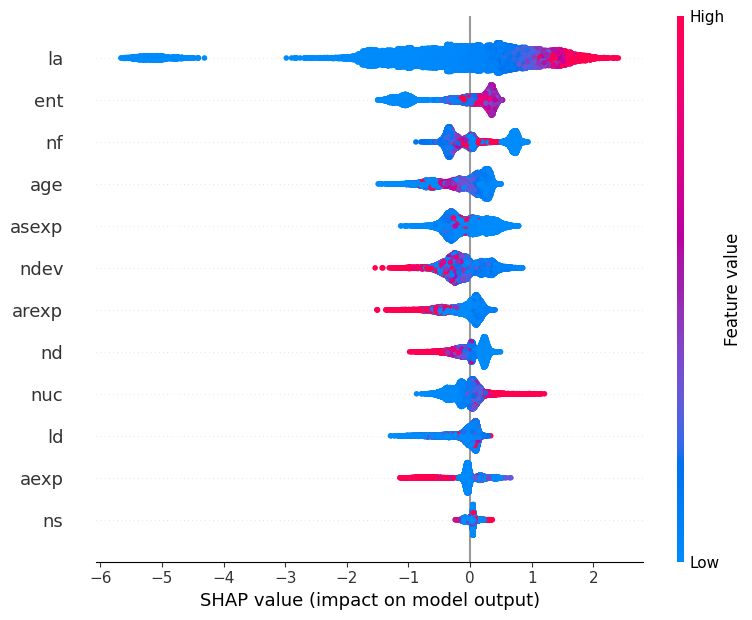

In [10]:
shap.summary_plot(
    shap_values,
    X_test,
    show=False
)

plt.savefig(
    "/content/drive/MyDrive/JIT_bug_prediction/outputs/plots/shap_summary_plot.png",
    bbox_inches="tight"
)

plt.show()

## Summary Plot Interpretation

The SHAP summary plot ranks features according to their overall influence on model predictions.

Features appearing near the top contribute most strongly to defect prediction.

Color Representation:

- Red → High feature value
- Blue → Low feature value

Positive SHAP values increase the probability of a commit being classified as buggy, whereas negative SHAP values decrease that probability.

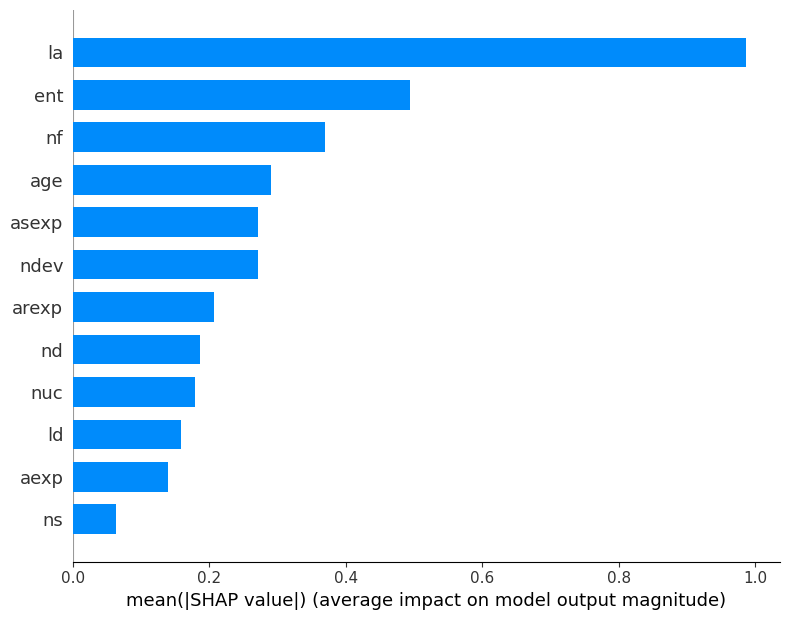

In [11]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    show=False
)

plt.savefig(
    "/content/drive/MyDrive/JIT_bug_prediction/outputs/plots/shap_bar_plot.png",
    bbox_inches="tight"
)

plt.show()

In [12]:
mean_shap = np.abs(shap_values).mean(axis=0)

importance = pd.DataFrame({
    "Feature": features,
    "Mean_SHAP": mean_shap
})

importance = importance.sort_values(
    by="Mean_SHAP",
    ascending=False
)

importance

,Feature,Mean_SHAP
0,la,0.987245
5,ent,0.494756
2,nf,0.369683
7,age,0.290775
11,asexp,0.270997
6,ndev,0.270880
10,arexp,0.206650
3,nd,0.185508
8,nuc,0.179015
1,ld,0.157652


In [13]:
importance.to_csv(
    "/content/drive/MyDrive/JIT_bug_prediction/outputs/tables/shap_feature_importance.csv",
    index=False
)

print("SHAP importance table saved.")

SHAP importance table saved.


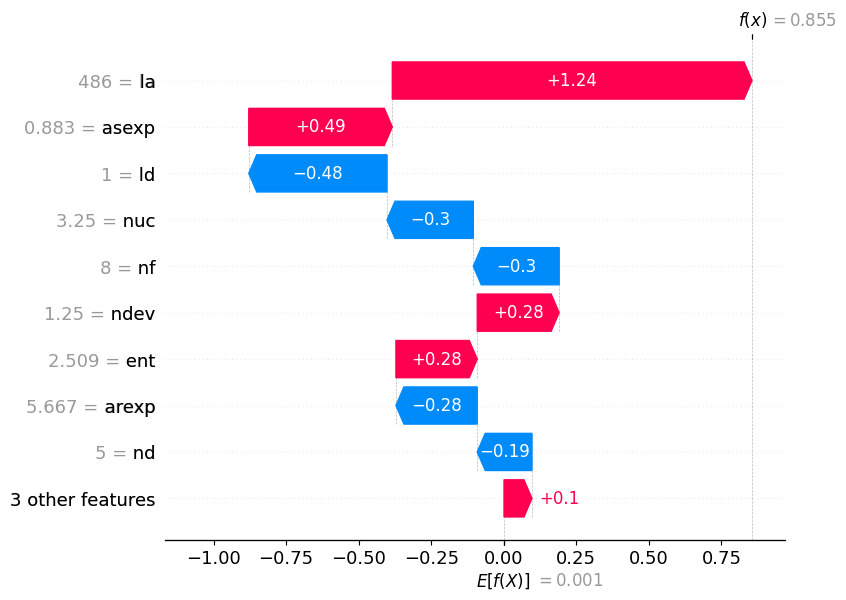

In [14]:
sample_index = 0

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[sample_index],
        base_values=explainer.expected_value,
        data=X_test.iloc[sample_index],
        feature_names=features
    ),
    show=False
)

plt.savefig(
    "/content/drive/MyDrive/JIT_bug_prediction/outputs/plots/shap_waterfall_plot.png",
    bbox_inches="tight"
)

plt.show()

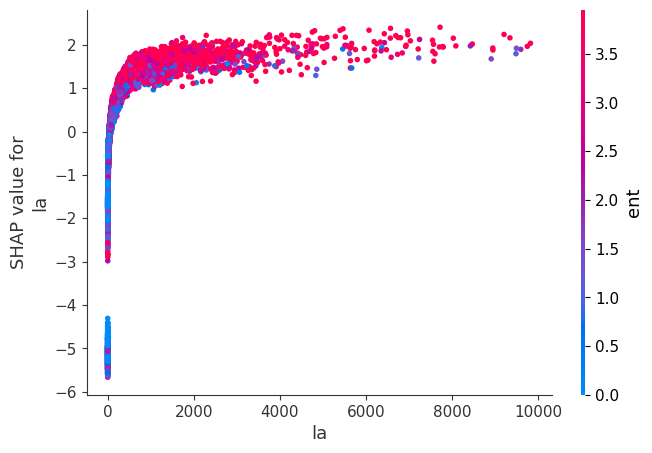

In [15]:
shap.dependence_plot(
    "la",
    shap_values,
    X_test,
    show=False
)

plt.savefig(
    "/content/drive/MyDrive/JIT_bug_prediction/outputs/plots/shap_dependence_la.png",
    bbox_inches="tight"
)

plt.show()

# Findings

## Global Feature Importance

SHAP analysis was performed to interpret the predictions generated by the final XGBoost model.

The analysis revealed that a small subset of software metrics contributes most strongly to defect prediction.

---

## Most Influential Features

The top software metrics according to SHAP values were:

1. LA (Lines Added)
2. ENT (Entropy)
3. NF (Number of Modified Files)
4. AGE (Average File Age)
5. ASEXP (Subsystem Experience)
6. NDEV (Number of Developers)

These metrics exhibited the largest contribution toward determining whether a commit would be classified as defect-inducing.

---

## Software Engineering Interpretation

The SHAP results indicate that commits involving large code additions are substantially more likely to introduce defects.

High entropy values suggest that code modifications are distributed across multiple files, increasing complexity and making defects more likely.

Commits touching a larger number of files also contribute strongly to defect proneness, reflecting the increased difficulty of coordinating widespread code changes.

Historical metrics such as AGE and NDEV further influence predictions, indicating that older files and files modified by multiple developers tend to exhibit higher defect risk.

Developer experience metrics, particularly ASEXP, also play an important role, suggesting that familiarity with a subsystem influences software quality.

---

## Consistency with Previous Models

The SHAP rankings closely align with the feature importance results obtained from Random Forest and XGBoost.

Both analyses identified the following metrics among the most influential:

- LA
- ENT
- NF
- AGE

The consistency between tree-based feature importance and SHAP explanations increases confidence in the reliability and interpretability of the model.

---

## Explainability of Individual Predictions

The SHAP waterfall plot demonstrates how individual feature contributions combine to produce a final prediction.

Positive SHAP values increase the probability of a commit being classified as buggy, while negative SHAP values reduce that probability.

This capability provides transparency at the commit level and allows developers to understand why a specific commit is considered high-risk.

---

## Conclusion

The SHAP analysis confirms that the XGBoost model relies on meaningful software engineering metrics when predicting defect-inducing commits.

The most influential predictors are related to code size, change dispersion, file modification patterns, and developer experience, all of which are supported by prior Just-In-Time defect prediction literature.

The explainability results strengthen confidence in the proposed model and support the selection of XGBoost as the final model for Just-In-Time Software Bug Prediction.

In [17]:
import joblib

# Load all 3 saved models
lr_model  = joblib.load("/content/drive/MyDrive/JIT_bug_prediction/models/logistic_regression.pkl")
rf_model  = joblib.load("/content/drive/MyDrive/JIT_bug_prediction/models/random_forest.pkl")
xgb_model = joblib.load("/content/drive/MyDrive/JIT_bug_prediction/models/xgboost.pkl")

print("All 3 models loaded!")

All 3 models loaded!


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


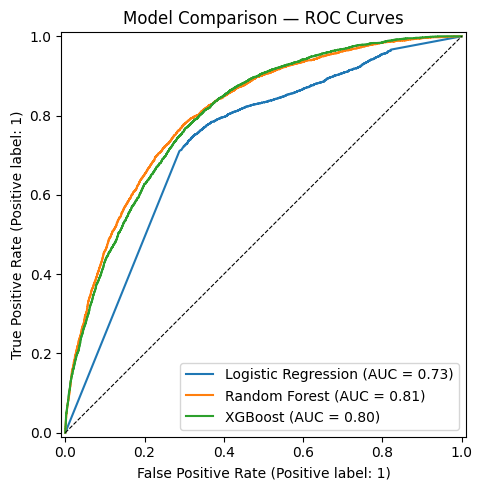

In [18]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(7, 5))

RocCurveDisplay.from_estimator(lr_model,  X_test, y_test, ax=ax, name="Logistic Regression")
RocCurveDisplay.from_estimator(rf_model,  X_test, y_test, ax=ax, name="Random Forest")
RocCurveDisplay.from_estimator(xgb_model, X_test, y_test, ax=ax, name="XGBoost")

ax.set_title("Model Comparison — ROC Curves")
ax.plot([0,1],[0,1],'k--', linewidth=0.8, label='Random Baseline')
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/JIT_bug_prediction/outputs/plots/roc_comparison.png",
            dpi=150, bbox_inches='tight')
plt.show()